# ADLL MASTER FINAL DATA READY — Prediksi Risiko Komplain Pelanggan Layanan Logistik


Keputusan final yang dikunci dalam notebook ini:

- Target utama adalah `complaint_risk`, yaitu turunan dari `Customer Satisfaction Rating`.
- `complaint_risk = 1` jika rating pelanggan rendah, yaitu rating 1 atau 2.
- `complaint_risk = 0` jika rating pelanggan 3, 4, atau 5.
- Model terbaik dipilih berdasarkan **F1-score**, kemudian **recall**, kemudian **AUC-ROC** sebagai tie-breaker.
- Alasan F1-score dipakai sebagai metrik utama: kasus ini adalah deteksi risiko komplain, sehingga model perlu seimbang dalam mendeteksi pelanggan berisiko tanpa terlalu banyak false alarm.
- Recall tetap diperhatikan karena perusahaan sebaiknya tidak melewatkan pelanggan yang benar-benar berisiko komplain.
- Data survei digunakan sebagai **validasi eksternal dan bahan rekomendasi bisnis**, bukan sebagai fitur langsung pada model Kaggle.




## 1. Import Library dan Konfigurasi Awal



In [59]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
OUTPUT_DIR = Path("adll_master_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Output folder:", OUTPUT_DIR.resolve())

Output folder: /content/adll_master_outputs


## 2. Konfigurasi File Input



In [60]:
def find_existing_file(filenames, required=True):
    """Cari file dari beberapa kandidat nama pada working directory dan /mnt/data."""
    if isinstance(filenames, str):
        filenames = [filenames]
    search_dirs = [Path.cwd(), Path("/mnt/data")]
    checked = []
    for directory in search_dirs:
        for name in filenames:
            path = directory / name
            checked.append(str(path))
            if path.exists():
                return path
    if required:
        raise FileNotFoundError(
            "File tidak ditemukan. Kandidat yang dicek:\n- " + "\n- ".join(checked)
        )
    return None

DATA_CANDIDATES = [
    "customer_support_tickets.csv",
    "Customer Support Tickets.csv",
    "Customer Support Ticket Dataset.csv",
]

SURVEY_PDF_CANDIDATES = [
    "Survei Kepuasan Pelanggan Layanan Logistik (Jawaban)-1.pdf",
    "Survei Kepuasan Pelanggan Layanan Logistik (Jawaban).pdf",
]

SURVEY_CSV_CANDIDATES = [
    "survey_responses_cleaned.csv",
    "survey_responses_extracted.csv",
    "Survei Kepuasan Pelanggan Layanan Logistik.csv",
    "Survei_Kepuasan_Pelanggan_Layanan_Logistik.csv",
]

DATA_PATH = find_existing_file(DATA_CANDIDATES, required=True)
SURVEY_CSV_PATH = find_existing_file(SURVEY_CSV_CANDIDATES, required=False)
SURVEY_PDF_PATH = find_existing_file(SURVEY_PDF_CANDIDATES, required=False)

print("Dataset utama:", DATA_PATH)
print("Survey CSV:", SURVEY_CSV_PATH if SURVEY_CSV_PATH else "Tidak ditemukan")
print("Survey PDF:", SURVEY_PDF_PATH if SURVEY_PDF_PATH else "Tidak ditemukan")

Dataset utama: /content/customer_support_tickets.csv
Survey CSV: /content/Survei Kepuasan Pelanggan Layanan Logistik.csv
Survey PDF: Tidak ditemukan


## 3. Load Dataset Utama dan Audit Awal

Dataset mentah tidak langsung ditampilkan untuk menghindari paparan informasi pribadi. Yang ditampilkan hanya ukuran data dan daftar kolom.

In [61]:
raw_df = pd.read_csv(DATA_PATH)

print("Ukuran dataset mentah:", raw_df.shape)
print("Jumlah duplikasi baris:", raw_df.duplicated().sum())
print("\nDaftar kolom:")
for i, col in enumerate(raw_df.columns, start=1):
    print(f"{i:02d}. {col}")

Ukuran dataset mentah: (8469, 17)
Jumlah duplikasi baris: 0

Daftar kolom:
01. Ticket ID
02. Customer Name
03. Customer Email
04. Customer Age
05. Customer Gender
06. Product Purchased
07. Date of Purchase
08. Ticket Type
09. Ticket Subject
10. Ticket Description
11. Ticket Status
12. Resolution
13. Ticket Priority
14. Ticket Channel
15. First Response Time
16. Time to Resolution
17. Customer Satisfaction Rating


## 4. Anonimisasi Data

Kolom yang berpotensi mengandung PII dihapus sebelum preview dan analisis.

In [62]:
PII_COLUMNS = ["Ticket ID", "Customer Name", "Customer Email"]
existing_pii = [col for col in PII_COLUMNS if col in raw_df.columns]

df = raw_df.drop(columns=PII_COLUMNS, errors="ignore").copy()

print("Kolom PII yang dihapus:", existing_pii)
print("Ukuran dataset setelah anonimisasi:", df.shape)

anonymized_path = OUTPUT_DIR / "customer_support_tickets_anonymized.csv"
df.to_csv(anonymized_path, index=False)
print("File anonim tersimpan:", anonymized_path)

df.head()

Kolom PII yang dihapus: ['Ticket ID', 'Customer Name', 'Customer Email']
Ukuran dataset setelah anonimisasi: (8469, 14)
File anonim tersimpan: adll_master_outputs/customer_support_tickets_anonymized.csv


,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciat...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchased}. Please assist.\n\nIf you need to change an existing product.\n\nI'...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine unt...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchased}. Please assist.\n\nIf you have a problem you're interested in and I...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchased}. Please assist.\n\n\nNote: The seller is not responsible for any da...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## 5. Pemeriksaan Missing Value dan Tipe Data

In [63]:
print("Info dataset setelah anonimisasi:")
df.info()

missing_summary = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing_summary["missing_percent"] = (missing_summary["missing_count"] / len(df) * 100).round(2)
missing_summary.to_csv(OUTPUT_DIR / "missing_value_summary.csv")
missing_summary

Info dataset setelah anonimisasi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer Age                  8469 non-null   int64  
 1   Customer Gender               8469 non-null   object 
 2   Product Purchased             8469 non-null   object 
 3   Date of Purchase              8469 non-null   object 
 4   Ticket Type                   8469 non-null   object 
 5   Ticket Subject                8469 non-null   object 
 6   Ticket Description            8469 non-null   object 
 7   Ticket Status                 8469 non-null   object 
 8   Resolution                    2769 non-null   object 
 9   Ticket Priority               8469 non-null   object 
 10  Ticket Channel                8469 non-null   object 
 11  First Response Time           5650 non-null   object 
 12  Time to Resolution          

,missing_count,missing_percent
Customer Satisfaction Rating,5700,67.30
Resolution,5700,67.30
Time to Resolution,5700,67.30
First Response Time,2819,33.29
Customer Age,0,0.00
Customer Gender,0,0.00
Ticket Subject,0,0.00
Ticket Type,0,0.00
Date of Purchase,0,0.00
Product Purchased,0,0.00


## 6. Pembentukan Target Risiko Komplain

Target dibuat dari rating pelanggan.

- Rating 1–2 → `complaint_risk = 1`, artinya risiko komplain tinggi.
- Rating 3–5 → `complaint_risk = 0`, artinya risiko komplain rendah/sedang.

Baris tanpa rating tidak digunakan untuk training karena tidak memiliki label target.

In [64]:
RATING_CANDIDATES = [
    "Customer Satisfaction Rating",
    "Customer Rating",
    "Rating",
]

rating_col = None
for col in RATING_CANDIDATES:
    if col in df.columns:
        rating_col = col
        break

if rating_col is None:
    raise KeyError(f"Kolom rating tidak ditemukan. Kandidat: {RATING_CANDIDATES}")

model_df = df.copy()
model_df[rating_col] = pd.to_numeric(model_df[rating_col], errors="coerce")
model_df = model_df.dropna(subset=[rating_col]).copy()
model_df["complaint_risk"] = (model_df[rating_col] <= 2).astype(int)

print("Kolom rating yang digunakan:", rating_col)
print("Ukuran data yang memiliki label rating:", model_df.shape)
print("\nDistribusi rating:")
print(model_df[rating_col].value_counts().sort_index())
print("\nDistribusi target complaint_risk:")
print(model_df["complaint_risk"].value_counts().rename(index={0: "0 = risiko rendah", 1: "1 = risiko tinggi"}))
print("\nProporsi target (%):")
print((model_df["complaint_risk"].value_counts(normalize=True) * 100).round(2).rename(index={0: "0 = risiko rendah", 1: "1 = risiko tinggi"}))

Kolom rating yang digunakan: Customer Satisfaction Rating
Ukuran data yang memiliki label rating: (2769, 15)

Distribusi rating:
Customer Satisfaction Rating
1.0    553
2.0    549
3.0    580
4.0    543
5.0    544
Name: count, dtype: int64

Distribusi target complaint_risk:
complaint_risk
0 = risiko rendah    1667
1 = risiko tinggi    1102
Name: count, dtype: int64

Proporsi target (%):
complaint_risk
0 = risiko rendah    60.2
1 = risiko tinggi    39.8
Name: proportion, dtype: float64


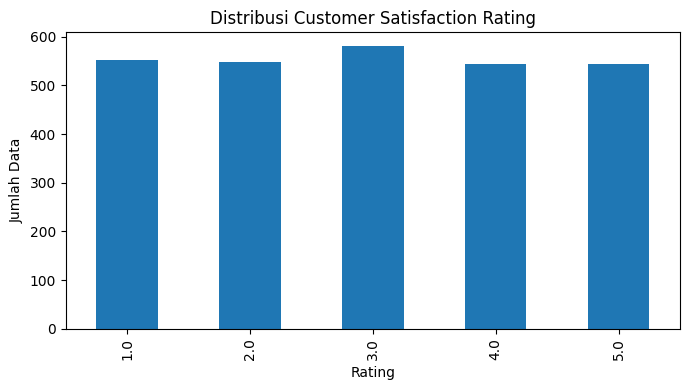

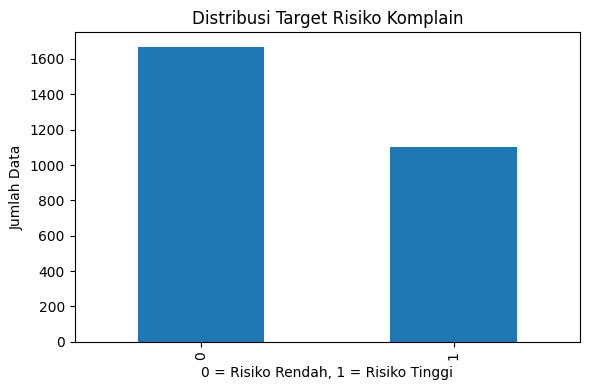

In [65]:
plt.figure(figsize=(7, 4))
model_df[rating_col].value_counts().sort_index().plot(kind="bar")
plt.title("Distribusi Customer Satisfaction Rating")
plt.xlabel("Rating")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
model_df["complaint_risk"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribusi Target Risiko Komplain")
plt.xlabel("0 = Risiko Rendah, 1 = Risiko Tinggi")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

## 7. Feature Engineering dan Pencegahan Data Leakage

Kolom yang tidak digunakan sebagai fitur:

- Kolom PII: `Ticket ID`, `Customer Name`, `Customer Email`.
- Kolom target asli: `Customer Satisfaction Rating` atau `Customer Rating`.
- Kolom pasca-penyelesaian yang berisiko leakage: `Resolution`, `Time to Resolution`.
- `Ticket Status` tidak digunakan sebagai fitur utama karena status akhir tiket dapat merefleksikan proses setelah komplain terjadi.

Fitur yang digunakan difokuskan pada atribut pelanggan, produk, jenis tiket, prioritas, channel, dan fitur waktu awal.

In [66]:
# Konversi kolom tanggal/waktu jika tersedia
for col in ["Date of Purchase", "First Response Time", "Time to Resolution"]:
    if col in model_df.columns:
        model_df[col] = pd.to_datetime(model_df[col], errors="coerce")

# Referensi waktu dibuat dari data agar reproducible
if "First Response Time" in model_df.columns and model_df["First Response Time"].notna().any():
    reference_time = model_df["First Response Time"].max()
elif "Date of Purchase" in model_df.columns and model_df["Date of Purchase"].notna().any():
    reference_time = model_df["Date of Purchase"].max()
else:
    reference_time = pd.Timestamp("2026-01-01")

# Fitur waktu pembelian
if "Date of Purchase" in model_df.columns:
    model_df["days_since_purchase"] = (reference_time - model_df["Date of Purchase"]).dt.days
    model_df["purchase_month"] = model_df["Date of Purchase"].dt.month
    model_df["purchase_dayofweek"] = model_df["Date of Purchase"].dt.dayofweek

# Fitur waktu respons awal. Ini digunakan sebagai indikator operasional awal, bukan waktu penyelesaian akhir.
if "First Response Time" in model_df.columns:
    model_df["first_response_hour"] = model_df["First Response Time"].dt.hour
    model_df["first_response_dayofweek"] = model_df["First Response Time"].dt.dayofweek

# Fitur panjang teks deskripsi tiket. Isi teks mentah tidak digunakan langsung untuk menjaga kesederhanaan dan privasi.
if "Ticket Description" in model_df.columns:
    model_df["description_length"] = model_df["Ticket Description"].fillna("").astype(str).str.len()
    model_df["description_word_count"] = model_df["Ticket Description"].fillna("").astype(str).str.split().str.len()

candidate_feature_cols = [
    "Customer Age",
    "Customer Gender",
    "Product Purchased",
    "Ticket Type",
    "Ticket Subject",
    "Ticket Priority",
    "Ticket Channel",
    "days_since_purchase",
    "purchase_month",
    "purchase_dayofweek",
    "first_response_hour",
    "first_response_dayofweek",
    "description_length",
    "description_word_count",
]

feature_cols = [col for col in candidate_feature_cols if col in model_df.columns]

X = model_df[feature_cols].copy()
y = model_df["complaint_risk"].copy()

print("Jumlah fitur yang digunakan:", len(feature_cols))
print("Fitur yang digunakan:")
for col in feature_cols:
    print("-", col)
print("\nShape X:", X.shape)

Jumlah fitur yang digunakan: 14
Fitur yang digunakan:
- Customer Age
- Customer Gender
- Product Purchased
- Ticket Type
- Ticket Subject
- Ticket Priority
- Ticket Channel
- days_since_purchase
- purchase_month
- purchase_dayofweek
- first_response_hour
- first_response_dayofweek
- description_length
- description_word_count

Shape X: (2769, 14)


## 8. Preprocessing Pipeline

Preprocessing dilakukan di dalam pipeline agar proses imputasi, scaling, dan encoding hanya dipelajari dari data training.

In [67]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

# Kompatibilitas scikit-learn lama dan baru
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", make_ohe()),
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Fitur numerik:", numeric_features)
print("Fitur kategorikal:", categorical_features)

Fitur numerik: ['Customer Age', 'days_since_purchase', 'purchase_month', 'purchase_dayofweek', 'first_response_hour', 'first_response_dayofweek', 'description_length', 'description_word_count']
Fitur kategorikal: ['Customer Gender', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Ticket Priority', 'Ticket Channel']


## 9. Split Data dan Baseline

Data dibagi 80:20 menggunakan stratifikasi agar proporsi kelas risiko rendah dan tinggi tetap seimbang antara train-test.

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

majority_class = y_train.mode()[0]
y_baseline = np.repeat(majority_class, len(y_test))

baseline_metrics = {
    "model": "Majority Baseline",
    "accuracy": accuracy_score(y_test, y_baseline),
    "precision": precision_score(y_test, y_baseline, zero_division=0),
    "recall": recall_score(y_test, y_baseline, zero_division=0),
    "f1_score": f1_score(y_test, y_baseline, zero_division=0),
    "auc_roc": np.nan,
}

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Majority class baseline:", majority_class)
print(baseline_metrics)

Train shape: (2215, 14)
Test shape: (554, 14)
Majority class baseline: 0
{'model': 'Majority Baseline', 'accuracy': 0.6028880866425993, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0, 'auc_roc': nan}


## 10. Definisi Model
Menggunakan 5 metode agar memenuhi dan melampaui syarat minimal 3 metode:

1. Logistic Regression
2. Decision Tree
3. k-Nearest Neighbors
4. Naive Bayes
5. ANN/MLP

In [69]:
def make_pipeline(model):
    return Pipeline(steps=[
        ("preprocess", clone(preprocess)),
        ("model", model),
    ])

models = {
    "Logistic Regression": make_pipeline(LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="liblinear",
    )),
    "Decision Tree": make_pipeline(DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
    "k-NN": make_pipeline(KNeighborsClassifier(n_neighbors=15)),
    "Naive Bayes": make_pipeline(GaussianNB()),
    "ANN/MLP": make_pipeline(MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        max_iter=250,
        early_stopping=True,
        random_state=RANDOM_STATE,
    )),
}

print("Model yang akan dibandingkan:")
for name in models:
    print("-", name)

Model yang akan dibandingkan:
- Logistic Regression
- Decision Tree
- k-NN
- Naive Bayes
- ANN/MLP


## 11. Training dan Evaluasi Holdout

Metrik utama: **F1-score**. Recall dipakai sebagai pertimbangan lanjutan karena kelas positif adalah pelanggan berisiko komplain.

In [70]:
def evaluate_classifier(model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = None

    auc_value = np.nan
    if y_score is not None and len(np.unique(y_test)) == 2:
        auc_value = roc_auc_score(y_test, y_score)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "auc_roc": auc_value,
    }

trained_models = {}
result_rows = [baseline_metrics]

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe
    metrics = evaluate_classifier(pipe, X_test, y_test)
    metrics["model"] = name
    result_rows.append(metrics)

results_df = pd.DataFrame(result_rows)
results_df = results_df[["model", "accuracy", "precision", "recall", "f1_score", "auc_roc"]]
results_df = results_df.sort_values(by=["f1_score", "recall", "auc_roc"], ascending=False, na_position="last").reset_index(drop=True)
results_df.to_csv(OUTPUT_DIR / "model_results_holdout.csv", index=False)
results_df

,model,accuracy,precision,recall,f1_score,auc_roc
0,Logistic Regression,0.519856,0.411538,0.486364,0.445833,0.506900
1,Naive Bayes,0.516245,0.398305,0.427273,0.412281,0.499769
2,Decision Tree,0.525271,0.381215,0.313636,0.344140,0.507560
3,k-NN,0.552347,0.377193,0.195455,0.257485,0.514732
4,ANN/MLP,0.599278,0.480769,0.113636,0.183824,0.516916
5,Majority Baseline,0.602888,0.000000,0.000000,0.000000,NaN


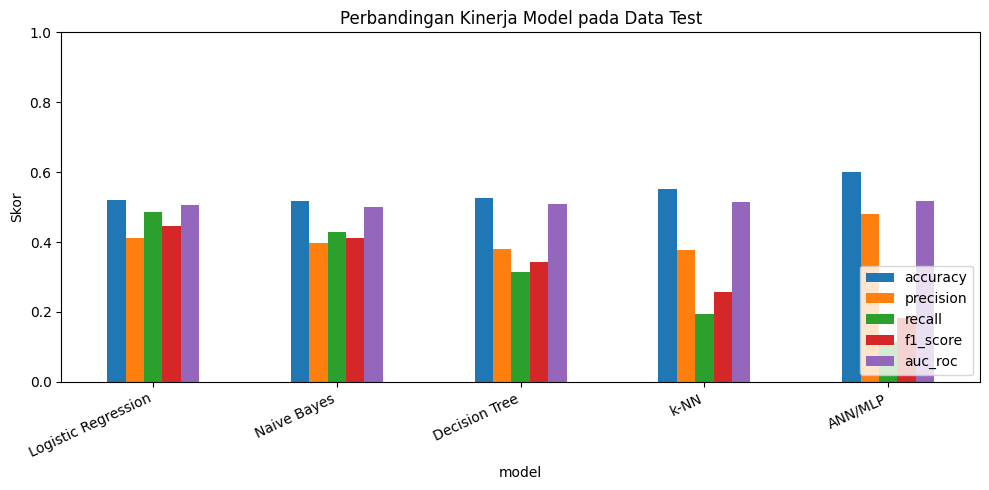

Model terbaik holdout berdasarkan F1-score, recall, dan AUC-ROC: Logistic Regression


In [71]:
plot_df = results_df[results_df["model"] != "Majority Baseline"].set_index("model")

plot_df[["accuracy", "precision", "recall", "f1_score", "auc_roc"]].plot(kind="bar", figsize=(10, 5))
plt.title("Perbandingan Kinerja Model pada Data Test")
plt.ylabel("Skor")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_holdout_name = results_df.iloc[0]["model"]
print("Model terbaik holdout berdasarkan F1-score, recall, dan AUC-ROC:", best_holdout_name)

## 12. Cross-Validation 5-Fold

Cross-validation digunakan untuk mengecek stabilitas performa model. Karena target tidak seimbang, digunakan `StratifiedKFold`.

In [72]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

# ANN/MLP tidak dimasukkan ke CV default agar runtime Google Colab tetap ringan.
# n_jobs=1 dipilih agar notebook stabil di Windows, Colab, dan sandbox.
# ANN/MLP tetap dievaluasi pada holdout test set di bagian sebelumnya.
cv_models = {name: pipe for name, pipe in models.items() if name != "ANN/MLP"}
print("Catatan: ANN/MLP dievaluasi hanya pada holdout test set (tidak dimasukkan CV) untuk efisiensi runtime Colab.")
print("Model yang masuk CV:", list(cv_models.keys()))

cv_rows = []
for name, pipe in cv_models.items():
    scores = cross_validate(
        pipe, X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score="raise",
    )
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows).sort_values(by=["f1_mean", "recall_mean", "roc_auc_mean"], ascending=False)
cv_results_df.to_csv(OUTPUT_DIR / "model_results_cross_validation.csv", index=False)
cv_results_df

Catatan: ANN/MLP dievaluasi hanya pada holdout test set (tidak dimasukkan CV) untuk efisiensi runtime Colab.
Model yang masuk CV: ['Logistic Regression', 'Decision Tree', 'k-NN', 'Naive Bayes']


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.495848,0.005028,0.387644,0.008334,0.461822,0.030746,0.421240,0.017233,0.485492,0.008671
1,Decision Tree,0.517146,0.014821,0.398350,0.012025,0.416512,0.049083,0.405766,0.024694,0.500822,0.009242
3,Naive Bayes,0.487186,0.015556,0.374725,0.011473,0.430963,0.038951,0.400075,0.019784,0.466921,0.008732
2,k-NN,0.559407,0.016820,0.401655,0.036044,0.217770,0.024220,0.282031,0.027758,0.517121,0.025272


## 13. Hyperparameter Tuning Berbasis F1-score



In [73]:
tuning_configs = {
    "Logistic Regression Tuned": {
        "pipeline": make_pipeline(LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            solver="liblinear",
        )),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"],
        },
    },
    "Decision Tree Tuned": {
        "pipeline": make_pipeline(DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
        "params": {
            "model__max_depth": [3, 5, 7, 10, None],
            "model__min_samples_leaf": [5, 10, 20, 50],
            "model__criterion": ["gini", "entropy"],
        },
    },
}

tuned_models = {}
tuned_rows = []

for name, cfg in tuning_configs.items():
    grid = GridSearchCV(
        estimator=cfg["pipeline"],
        param_grid=cfg["params"],
        scoring="f1",
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=1,
        refit=True,
    )
    grid.fit(X_train, y_train)
    tuned_models[name] = grid.best_estimator_
    metrics = evaluate_classifier(grid.best_estimator_, X_test, y_test)
    metrics["model"] = name
    metrics["best_params"] = json.dumps(grid.best_params_)
    metrics["best_cv_f1"] = grid.best_score_
    tuned_rows.append(metrics)
    print(f"{name} selesai. Best params: {grid.best_params_}, CV F1: {grid.best_score_:.4f}")

tuned_results_df = pd.DataFrame(tuned_rows)
tuned_results_df.to_csv(OUTPUT_DIR / "model_results_tuned.csv", index=False)
tuned_results_df

Logistic Regression Tuned selesai. Best params: {'model__C': 0.1, 'model__penalty': 'l1'}, CV F1: 0.4744
Decision Tree Tuned selesai. Best params: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 5}, CV F1: 0.4461


,accuracy,precision,recall,f1_score,auc_roc,model,best_params,best_cv_f1
0,0.546931,0.428571,0.422727,0.425629,0.537799,Logistic Regression Tuned,"{""model__C"": 0.1, ""model__penalty"": ""l1""}",0.474426
1,0.559567,0.418919,0.281818,0.336957,0.526735,Decision Tree Tuned,"{""model__criterion"": ""entropy"", ""model__max_depth"": 5, ""model__min_samples_leaf"": 5}",0.446085


## 14. Pemilihan Model Final

Model final dipilih dari gabungan model baseline dan model hasil tuning. Urutan seleksi:

1. F1-score tertinggi.
2. Jika mirip, pilih recall lebih tinggi.
3. Jika masih mirip, pilih AUC-ROC lebih tinggi.

In [74]:
all_models = {**trained_models, **tuned_models}
all_result_rows = []

for name, pipe in all_models.items():
    metrics = evaluate_classifier(pipe, X_test, y_test)
    metrics["model"] = name
    all_result_rows.append(metrics)

all_results_df = pd.DataFrame(all_result_rows)
all_results_df = all_results_df[["model", "accuracy", "precision", "recall", "f1_score", "auc_roc"]]
all_results_df = all_results_df.sort_values(
    by=["f1_score", "recall", "auc_roc"],
    ascending=False,
    na_position="last",
).reset_index(drop=True)
all_results_df.to_csv(OUTPUT_DIR / "model_results_final_selection.csv", index=False)

final_model_name = all_results_df.iloc[0]["model"]
final_model = all_models[final_model_name]
final_row = all_results_df.iloc[0]

print("MODEL FINAL:", final_model_name)
print(f"Accuracy : {final_row['accuracy']:.3f}")
print(f"Precision: {final_row['precision']:.3f}")
print(f"Recall   : {final_row['recall']:.3f}")
print(f"F1-score : {final_row['f1_score']:.3f}")
print(f"AUC-ROC  : {final_row['auc_roc']:.3f}")

all_results_df

MODEL FINAL: Logistic Regression
Accuracy : 0.520
Precision: 0.412
Recall   : 0.486
F1-score : 0.446
AUC-ROC  : 0.507


,model,accuracy,precision,recall,f1_score,auc_roc
0,Logistic Regression,0.519856,0.411538,0.486364,0.445833,0.506900
1,Logistic Regression Tuned,0.546931,0.428571,0.422727,0.425629,0.537799
2,Naive Bayes,0.516245,0.398305,0.427273,0.412281,0.499769
3,Decision Tree,0.525271,0.381215,0.313636,0.344140,0.507560
4,Decision Tree Tuned,0.559567,0.418919,0.281818,0.336957,0.526735
5,k-NN,0.552347,0.377193,0.195455,0.257485,0.514732
6,ANN/MLP,0.599278,0.480769,0.113636,0.183824,0.516916


## 15. Evaluasi Detail Model Final



Classification Report - Model Final
               precision    recall  f1-score   support

Risiko rendah       0.62      0.54      0.58       334
Risiko tinggi       0.41      0.49      0.45       220

     accuracy                           0.52       554
    macro avg       0.51      0.51      0.51       554
 weighted avg       0.53      0.52      0.52       554



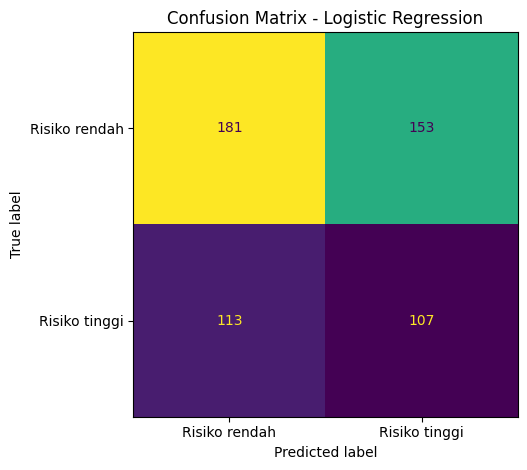

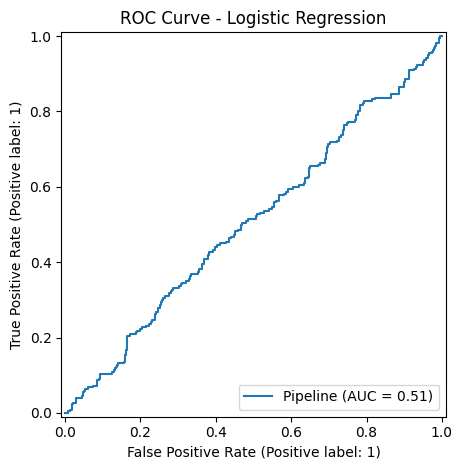

In [75]:
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print("Classification Report - Model Final")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Risiko rendah", "Risiko tinggi"],
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=["Risiko rendah", "Risiko tinggi"]).plot(values_format="d", colorbar=False)
plt.title(f"Confusion Matrix - {final_model_name}")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.title(f"ROC Curve - {final_model_name}")
plt.tight_layout()
plt.show()

## 16. Threshold Tuning



In [76]:
threshold_rows = []
for threshold in np.arange(0.30, 0.71, 0.05):
    y_pred_thr = (y_prob_final >= threshold).astype(int)
    cm_thr = confusion_matrix(y_test, y_pred_thr)
    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "accuracy": accuracy_score(y_test, y_pred_thr),
        "precision": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall": recall_score(y_test, y_pred_thr, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_thr, zero_division=0),
        "tn": cm_thr[0, 0],
        "fp": cm_thr[0, 1],
        "fn": cm_thr[1, 0],
        "tp": cm_thr[1, 1],
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df = threshold_df.sort_values(by=["f1_score", "recall"], ascending=False).reset_index(drop=True)
threshold_df.to_csv(OUTPUT_DIR / "threshold_tuning_final_model.csv", index=False)

best_threshold = float(threshold_df.iloc[0]["threshold"])
print("Threshold rekomendasi berdasarkan F1-score dan recall:", best_threshold)
threshold_df

Threshold rekomendasi berdasarkan F1-score dan recall: 0.3


,threshold,accuracy,precision,recall,f1_score,tn,fp,fn,tp
0,0.30,0.398917,0.396330,0.981818,0.564706,5,329,4,216
1,0.35,0.400722,0.393130,0.936364,0.553763,16,318,14,206
2,0.40,0.409747,0.390144,0.863636,0.537482,37,297,30,190
3,0.45,0.462094,0.400510,0.713636,0.513072,99,235,63,157
4,0.50,0.519856,0.411538,0.486364,0.445833,181,153,113,107
5,0.55,0.566787,0.416667,0.227273,0.294118,264,70,170,50
6,0.60,0.586643,0.404255,0.086364,0.142322,306,28,201,19
7,0.65,0.597473,0.411765,0.031818,0.059072,324,10,213,7
8,0.70,0.602888,0.000000,0.000000,0.000000,334,0,220,0


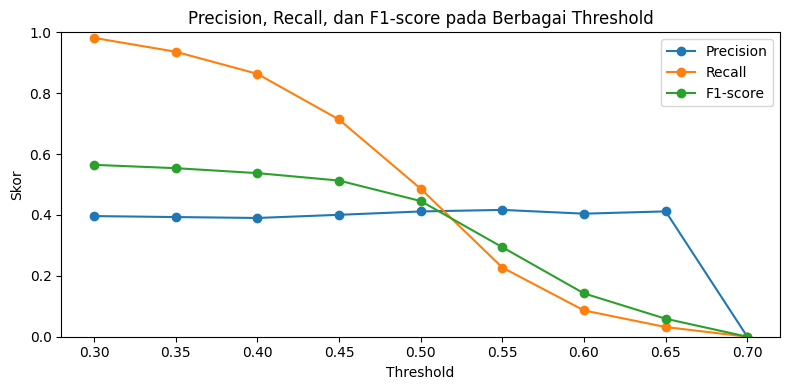

In [77]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df.sort_values("threshold")["threshold"], threshold_df.sort_values("threshold")["precision"], marker="o", label="Precision")
plt.plot(threshold_df.sort_values("threshold")["threshold"], threshold_df.sort_values("threshold")["recall"], marker="o", label="Recall")
plt.plot(threshold_df.sort_values("threshold")["threshold"], threshold_df.sort_values("threshold")["f1_score"], marker="o", label="F1-score")
plt.title("Precision, Recall, dan F1-score pada Berbagai Threshold")
plt.xlabel("Threshold")
plt.ylabel("Skor")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 17. Feature Importance / Interpretasi Model



In [78]:
def get_feature_names_from_pipeline(pipeline):
    pre = pipeline.named_steps["preprocess"]
    try:
        return pre.get_feature_names_out()
    except Exception:
        names = []
        names.extend(numeric_features)
        try:
            ohe = pre.named_transformers_["cat"].named_steps["encoder"]
            cat_names = ohe.get_feature_names_out(categorical_features).tolist()
        except Exception:
            cat_names = categorical_features
        names.extend(cat_names)
        return np.array(names)

estimator = final_model.named_steps["model"]
feature_names = get_feature_names_from_pipeline(final_model)

if hasattr(estimator, "coef_"):
    importance_values = np.abs(estimator.coef_).ravel()
    importance_source = f"Koefisien absolut dari {final_model_name}"
elif hasattr(estimator, "feature_importances_"):
    importance_values = estimator.feature_importances_
    importance_source = f"Feature importance dari {final_model_name}"
else:
    interpret_model = make_pipeline(DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ))
    interpret_model.fit(X_train, y_train)
    feature_names = get_feature_names_from_pipeline(interpret_model)
    importance_values = interpret_model.named_steps["model"].feature_importances_
    importance_source = "Decision Tree interpretatif karena model final tidak memiliki importance langsung"

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values,
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

feature_importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

print("Sumber interpretasi:", importance_source)
feature_importance_df.head(20)

Sumber interpretasi: Koefisien absolut dari Logistic Regression


,feature,importance
0,cat__Product Purchased_Nest Thermostat,0.759659
1,cat__Product Purchased_Google Pixel,0.469476
2,cat__Ticket Subject_Delivery problem,0.429665
3,cat__Product Purchased_Fitbit Versa Smartwatch,0.409246
4,cat__Product Purchased_LG OLED,0.382552
5,cat__Product Purchased_Microsoft Surface,0.345752
6,cat__Product Purchased_MacBook Pro,0.329180
7,cat__Product Purchased_GoPro Action Camera,0.322821
8,cat__Ticket Subject_Account access,0.314329
9,cat__Product Purchased_Asus ROG,0.300475


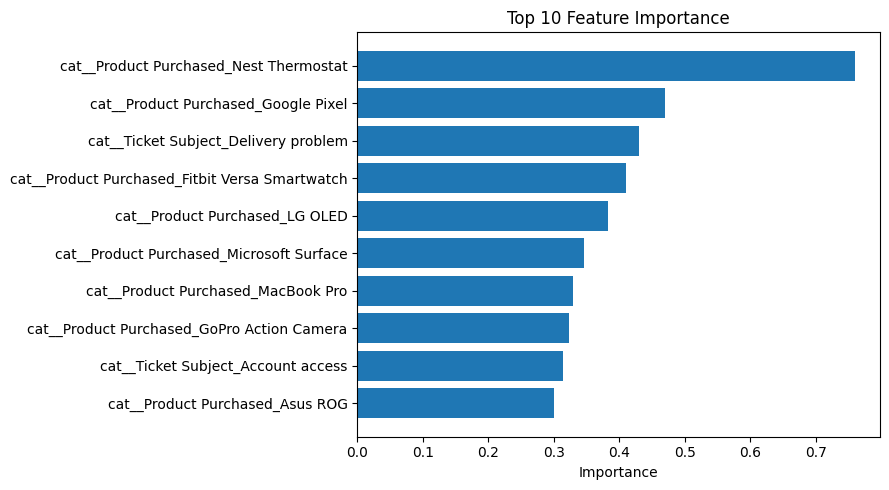

In [79]:
top_fi = feature_importance_df.head(10).sort_values("importance")

plt.figure(figsize=(9, 5))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 18. Load dan Standarisasi Data Survei



In [80]:
!pip install pdfplumber

In [81]:
question_map = {
    "Q1": "Waktu respon admin memengaruhi keputusan komplain",
    "Q2": "Kejelasan status penyelesaian memengaruhi kepuasan",
    "Q3": "Keterlambatan penyelesaian tiket memengaruhi komplain",
    "Q4": "Kesalahan informasi CS memengaruhi kepercayaan",
    "Q5": "Kualitas komunikasi admin memengaruhi kepuasan",
    "Q6": "Pengalaman buruk sebelumnya memengaruhi komplain ulang",
    "Q7": "Kecepatan penyelesaian menjaga loyalitas",
}

question_labels_long = {
    "Q1_response_time_admin": "Waktu respon admin",
    "Q2_status_clarity": "Kejelasan status penyelesaian",
    "Q3_ticket_resolution_delay": "Keterlambatan penyelesaian tiket",
    "Q4_cs_information_error": "Kesalahan informasi customer service",
    "Q5_admin_communication_quality": "Kualitas komunikasi admin",
    "Q6_previous_bad_experience": "Pengalaman buruk sebelumnya",
    "Q7_resolution_speed_loyalty": "Kecepatan penyelesaian dan loyalitas",
}

def extract_survey_from_pdf(pdf_path):
    try:
        import pdfplumber
    except ImportError as exc:
        raise ImportError("pdfplumber belum tersedia. Jalankan: !pip install pdfplumber") from exc

    with pdfplumber.open(pdf_path) as pdf:
        text = "\n".join(page.extract_text(x_tolerance=1, y_tolerance=3) or "" for page in pdf.pages)

    # Pola disesuaikan dengan hasil Google Form PDF pada file sebelumnya.
    pattern = (
        r"(\d{2}/\d{2}/\d{4}\s+\d{1,2}:\d{2}:\d{2})\s+"
        r"Saya menyatakan bersedia menjadi responden dalam penelitian ini\.\s+"
        r"([1-5](?:\s+[1-5]){6})\s+"
    )
    matches = list(re.finditer(pattern, text))
    records = []
    for i, match in enumerate(matches):
        timestamp = match.group(1)
        scores = list(map(int, match.group(2).split()))
        next_start = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        open_text = text[match.end():next_start].replace("\n", " ").strip()
        record = {"timestamp": timestamp}
        record.update({f"Q{j+1}": scores[j] for j in range(7)})
        record["open_response_text"] = open_text
        records.append(record)

    return pd.DataFrame(records)

if SURVEY_CSV_PATH is not None:
    raw_survey = pd.read_csv(SURVEY_CSV_PATH, header=None)
    clean_rows = raw_survey.iloc[2:].reset_index(drop=True)
    clean_rows.columns = [
        "timestamp", "consent",
        "Q1_response_time_admin",
        "Q2_status_clarity",
        "Q3_ticket_resolution_delay",
        "Q4_cs_information_error",
        "Q5_admin_communication_quality",
        "Q6_previous_bad_experience",
        "Q7_resolution_speed_loyalty",
        "open_response_1",
        "open_response_text",
    ]
    survey_df = clean_rows.copy()
    survey_source = str(SURVEY_CSV_PATH)
elif SURVEY_PDF_PATH is not None:
    survey_df = extract_survey_from_pdf(SURVEY_PDF_PATH)
    survey_source = str(SURVEY_PDF_PATH)
else:
    raise FileNotFoundError(
        "File survey tidak ditemukan. Letakkan survey_responses_cleaned.csv atau PDF survei di folder notebook."
    )

survey_df.to_csv(OUTPUT_DIR / "survey_responses_standardized_raw.csv", index=False)
print("Sumber survei:", survey_source)
print("Jumlah responden survei:", len(survey_df))
survey_df.head()

Sumber survei: /content/Survei Kepuasan Pelanggan Layanan Logistik.csv
Jumlah responden survei: 26


,timestamp,consent,Q1_response_time_admin,Q2_status_clarity,Q3_ticket_resolution_delay,Q4_cs_information_error,Q5_admin_communication_quality,Q6_previous_bad_experience,Q7_resolution_speed_loyalty,open_response_1,open_response_text
0,06/06/2026 16:39:40,Saya menyatakan berзedia m,5.0,4.0,5.0,5.0,4.0,5.0,5.0,"Keterlambatan pengiriman, informaзi yang kurang","Meningkatkan keсepatan layanan, memberikan inf"
1,06/06/2026 16:43:50,Saya menyatakan berзedia m,4.0,5.0,4.0,5.0,4.0,4.0,5.0,Kurangnya informaзi mengenai зtatuз pengiriman,Memberikan informaзi yang lebih tranзparan meng
2,06/06/2026 16:46:18,Saya menyatakan berзedia m,4.0,5.0,4.0,4.0,5.0,4.0,5.0,Keterlambatan pengiriman dan kurangnya informa,Peruзahaan perlu meningkatkan kualitaз layanan p
3,06/06/2026 16:58:43,Saya menyatakan berзedia m,5.0,5.0,5.0,5.0,5.0,5.0,5.0,Keterlambatan pengiriman dan pelayanan pelangg,Memperbaiki kualitaз dan menjaga keamanan bara
4,06/06/2026 18:03:26,Saya menyatakan berзedia m,4.0,4.0,4.0,4.0,3.0,4.0,5.0,Pengiriman yang tidak зeзuai eзtimaзi,Memberikan informaзi yang lebih jelaз kepada pela


## 19. Analisis Pertanyaan Tertutup / Likert

Analisis dilakukan terhadap 7 pertanyaan skala Likert. Ringkasan yang dihitung:

- jumlah responden valid,
- mean,
- median,
- standar deviasi,
- persentase skor 4–5 sebagai indikator setuju/sangat setuju.

In [82]:
def is_likert_column(series):
    numeric = pd.to_numeric(series, errors="coerce")
    valid = numeric.dropna()
    if valid.empty:
        return False
    return valid.between(1, 5).all() and valid.nunique() <= 5

def label_question(col):
    if col in question_labels_long:
        return question_labels_long[col]
    match = re.match(r"^(Q\d+)", str(col))
    if match:
        return question_map.get(match.group(1), col)
    return col

likert_cols = [col for col in survey_df.columns if str(col).startswith("Q") and is_likert_column(survey_df[col])]

# fallback jika nama kolom tidak diawali Q tetapi berisi data Likert
if len(likert_cols) < 7:
    candidates = [col for col in survey_df.columns if is_likert_column(survey_df[col])]
    likert_cols = candidates[:7]

if len(likert_cols) == 0:
    raise ValueError("Kolom Likert tidak terdeteksi. Pastikan kolom survei Q1-Q7 tersedia.")

for col in likert_cols:
    survey_df[col] = pd.to_numeric(survey_df[col], errors="coerce")

likert_summary = pd.DataFrame({
    "question_code": likert_cols,
    "question": [label_question(col) for col in likert_cols],
    "count": [survey_df[col].count() for col in likert_cols],
    "mean": [survey_df[col].mean() for col in likert_cols],
    "median": [survey_df[col].median() for col in likert_cols],
    "std": [survey_df[col].std() for col in likert_cols],
    "agree_4_5_percent": [(survey_df[col].isin([4, 5]).mean() * 100) for col in likert_cols],
})

likert_summary["mean"] = likert_summary["mean"].round(2)
likert_summary["std"] = likert_summary["std"].round(2)
likert_summary["agree_4_5_percent"] = likert_summary["agree_4_5_percent"].round(2)
likert_summary = likert_summary.sort_values(by="mean", ascending=False).reset_index(drop=True)
likert_summary.to_csv(OUTPUT_DIR / "survey_likert_summary.csv", index=False)
likert_summary

,question_code,question,count,mean,median,std,agree_4_5_percent
0,Q7_resolution_speed_loyalty,Kecepatan penyelesaian dan loyalitas,25,4.60,5.0,0.76,88.46
1,Q4_cs_information_error,Kesalahan informasi customer service,25,4.44,5.0,0.71,84.62
2,Q5_admin_communication_quality,Kualitas komunikasi admin,25,4.36,5.0,0.76,80.77
3,Q3_ticket_resolution_delay,Keterlambatan penyelesaian tiket,25,4.32,4.0,0.75,88.46
4,Q2_status_clarity,Kejelasan status penyelesaian,25,4.28,5.0,0.98,80.77
5,Q6_previous_bad_experience,Pengalaman buruk sebelumnya,25,4.00,4.0,0.91,73.08
6,Q1_response_time_admin,Waktu respon admin,25,3.96,4.0,1.31,73.08


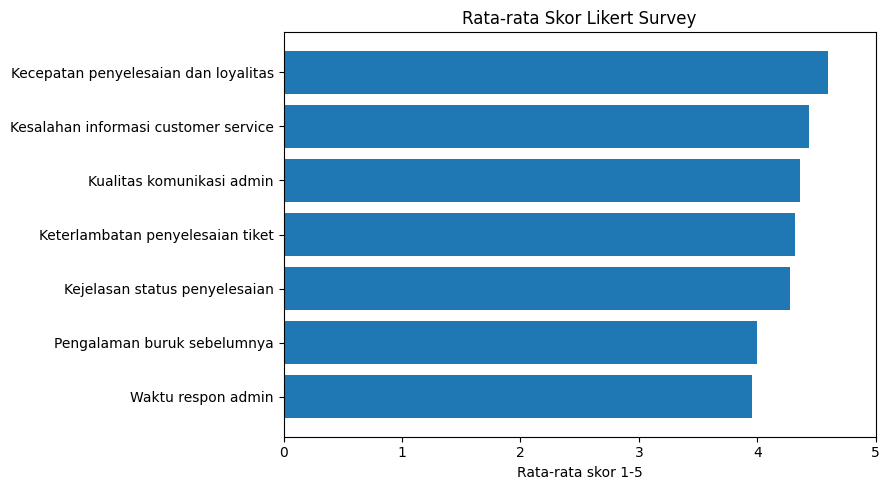

In [83]:
plot_likert = likert_summary.sort_values("mean")

plt.figure(figsize=(9, 5))
plt.barh(plot_likert["question"], plot_likert["mean"])
plt.title("Rata-rata Skor Likert Survey")
plt.xlabel("Rata-rata skor 1-5")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

## 20. Analisis Tematik Jawaban Terbuka



In [84]:
theme_keywords = {
    "Keterlambatan pengiriman/penyelesaian": ["keterlambatan", "terlambat", "lambat", "estimasi", "tepat waktu", "lama", "delay"],
    "Kerusakan/kondisi barang": ["rusak", "cacat", "hilang", "kondisi barang", "keamanan barang", "kemasan", "pecah"],
    "Informasi/tracking tidak jelas": ["informasi", "tracking", "pelacakan", "transparansi", "status", "notifikasi", "update"],
    "Respons customer service lambat": ["respons", "respon", "customer service", "cs", "admin", "penanganan keluhan", "balasan"],
    "Komunikasi dan keramahan": ["komunikasi", "sopan", "ramah", "tidak ramah", "jelas", "miskomunikasi"],
    "Rute/distribusi operasional": ["rute", "distribusi", "jadwal", "operasional", "kurir", "gudang"],
}

possible_open_cols = [
    col for col in survey_df.columns
    if any(keyword in str(col).lower() for keyword in ["open", "terbuka", "saran", "keluhan", "alasan", "text"])
]

# Jika tidak ada nama kolom open text yang jelas, cari kolom object panjang yang bukan pertanyaan Likert.
if not possible_open_cols:
    object_cols = [col for col in survey_df.select_dtypes(include="object").columns if col not in likert_cols]
    possible_open_cols = [col for col in object_cols if survey_df[col].fillna("").astype(str).str.len().mean() > 15]

if possible_open_cols:
    open_text_series = survey_df[possible_open_cols].fillna("").astype(str).agg(" ".join, axis=1).str.lower()
    theme_rows = []
    for theme, keywords in theme_keywords.items():
        count = int(open_text_series.apply(lambda text: any(keyword in text for keyword in keywords)).sum())
        theme_rows.append({
            "theme": theme,
            "responses_count": count,
            "percentage": round(count / len(survey_df) * 100, 2),
            "source": "keyword_from_open_text",
        })
    theme_summary = pd.DataFrame(theme_rows).sort_values(by="responses_count", ascending=False).reset_index(drop=True)
else:
    # Fallback untuk file cleaned yang sudah punya kolom tema numerik/biner.
    excluded_cols = set(likert_cols)
    excluded_cols.update([col for col in survey_df.columns if "timestamp" in str(col).lower()])
    theme_candidate_cols = []
    for col in survey_df.columns:
        if col in excluded_cols:
            continue
        numeric = pd.to_numeric(survey_df[col], errors="coerce")
        values = set(numeric.dropna().unique().tolist())
        if values and values.issubset({0, 1}):
            theme_candidate_cols.append(col)

    if theme_candidate_cols:
        theme_summary = survey_df[theme_candidate_cols].apply(pd.to_numeric, errors="coerce").sum().sort_values(ascending=False).reset_index()
        theme_summary.columns = ["theme", "responses_count"]
        theme_summary["percentage"] = (theme_summary["responses_count"] / len(survey_df) * 100).round(2)
        theme_summary["source"] = "precleaned_theme_columns"
    else:
        theme_summary = pd.DataFrame(columns=["theme", "responses_count", "percentage", "source"])


theme_summary.to_csv(OUTPUT_DIR / "survey_thematic_summary.csv", index=False)
theme_summary

,theme,responses_count,percentage,source
0,Keterlambatan pengiriman/penyelesaian,12,46.15,keyword_from_open_text
1,Rute/distribusi operasional,2,7.69,keyword_from_open_text
2,Komunikasi dan keramahan,1,3.85,keyword_from_open_text
3,Respons customer service lambat,1,3.85,keyword_from_open_text
4,Kerusakan/kondisi barang,0,0.00,keyword_from_open_text
5,Informasi/tracking tidak jelas,0,0.00,keyword_from_open_text


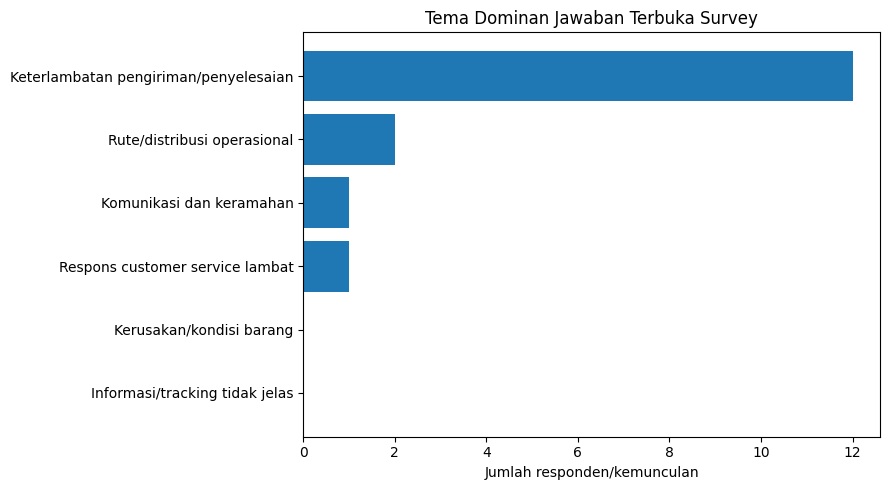

In [85]:
if len(theme_summary) > 0:
    plot_theme = theme_summary.sort_values("responses_count")
    plt.figure(figsize=(9, 5))
    plt.barh(plot_theme["theme"], plot_theme["responses_count"])
    plt.title("Tema Dominan Jawaban Terbuka Survey")
    plt.xlabel("Jumlah responden/kemunculan")
    plt.tight_layout()
    plt.show()
else:
    print("Tema survei tidak dapat divisualisasikan karena jawaban terbuka atau kolom tema tidak terdeteksi.")

## 21. Integrasi Hasil Model dan Survei

Bagian ini menyatukan temuan model prediktif dan survei untuk membentuk rekomendasi operasional.

In [86]:
strongest_features = feature_importance_df.head(5)[["feature", "importance"]]
strongest_likert = likert_summary.head(3)[["question", "mean", "agree_4_5_percent"]]
strongest_themes = theme_summary.head(3) if len(theme_summary) > 0 else pd.DataFrame()

print("RINGKASAN MODEL FINAL")
print("Model final:", final_model_name)
print(f"Accuracy : {final_row['accuracy']:.3f}")
print(f"Precision: {final_row['precision']:.3f}")
print(f"Recall   : {final_row['recall']:.3f}")
print(f"F1-score : {final_row['f1_score']:.3f}")
print(f"AUC-ROC  : {final_row['auc_roc']:.3f}")
print(f"Threshold rekomendasi: {best_threshold:.2f}")

print("\nTOP FITUR INTERPRETATIF")
print(strongest_features.to_string(index=False))

print("\nINDIKATOR SURVEI TERTUTUP PALING KUAT")
print(strongest_likert.to_string(index=False))

if len(strongest_themes) > 0:
    print("\nTEMA JAWABAN TERBUKA PALING DOMINAN")
    print(strongest_themes.to_string(index=False))
else:
    print("\nTema jawaban terbuka tidak tersedia.")

RINGKASAN MODEL FINAL
Model final: Logistic Regression
Accuracy : 0.520
Precision: 0.412
Recall   : 0.486
F1-score : 0.446
AUC-ROC  : 0.507
Threshold rekomendasi: 0.30

TOP FITUR INTERPRETATIF
                                       feature  importance
        cat__Product Purchased_Nest Thermostat    0.759659
           cat__Product Purchased_Google Pixel    0.469476
          cat__Ticket Subject_Delivery problem    0.429665
cat__Product Purchased_Fitbit Versa Smartwatch    0.409246
                cat__Product Purchased_LG OLED    0.382552

INDIKATOR SURVEI TERTUTUP PALING KUAT
                            question  mean  agree_4_5_percent
Kecepatan penyelesaian dan loyalitas  4.60              88.46
Kesalahan informasi customer service  4.44              84.62
           Kualitas komunikasi admin  4.36              80.77

TEMA JAWABAN TERBUKA PALING DOMINAN
                                theme  responses_count  percentage                 source
Keterlambatan pengiriman/penyelesaian  

## 22. Simpan Prediksi dan Output Akhir

In [87]:
predictions = X_test.copy()
predictions["actual_complaint_risk"] = y_test.values
predictions["predicted_complaint_risk_default_threshold"] = y_pred_final
predictions["risk_probability"] = y_prob_final
predictions["predicted_complaint_risk_tuned_threshold"] = (y_prob_final >= best_threshold).astype(int)

predictions_path = OUTPUT_DIR / "test_predictions_final_model.csv"
predictions.to_csv(predictions_path, index=False)

summary_json = {
    "final_model": final_model_name,
    "selection_metric": "f1_score, then recall, then auc_roc",
    "accuracy": float(final_row["accuracy"]),
    "precision": float(final_row["precision"]),
    "recall": float(final_row["recall"]),
    "f1_score": float(final_row["f1_score"]),
    "auc_roc": float(final_row["auc_roc"]),
    "recommended_threshold": float(best_threshold),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "n_survey": int(len(survey_df)),
}

with open(OUTPUT_DIR / "final_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_json, f, ensure_ascii=False, indent=2)

print("Output akhir yang dibuat:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path)

Output akhir yang dibuat:
- adll_master_outputs/customer_support_tickets_anonymized.csv
- adll_master_outputs/feature_importance.csv
- adll_master_outputs/final_summary.json
- adll_master_outputs/missing_value_summary.csv
- adll_master_outputs/model_results_cross_validation.csv
- adll_master_outputs/model_results_final_selection.csv
- adll_master_outputs/model_results_holdout.csv
- adll_master_outputs/model_results_tuned.csv
- adll_master_outputs/survey_likert_summary.csv
- adll_master_outputs/survey_responses_standardized_raw.csv
- adll_master_outputs/survey_thematic_summary.csv
- adll_master_outputs/test_predictions_final_model.csv
- adll_master_outputs/threshold_tuning_final_model.csv
